In [ ]:
import numpy as np


# ============================================================
# Parameter sampling
# ============================================================

def sample_heston_parameters(n_paths, rng):
    """
    Draw one distinct Heston parameter vector per simulated stock.

    Parameters returned:
        v0       : initial variance
        kappa    : variance mean-reversion speed
        theta    : long-run variance
        sigma_v  : volatility of variance ("vol of vol")
        rho      : correlation between price and variance shocks
    """

    # Initial annualized volatility: roughly 10% to 45%
    initial_vol = rng.uniform(0.10, 0.45, size=n_paths)
    v0 = initial_vol ** 2

    # Long-run annualized volatility: roughly 10% to 45%
    long_run_vol = rng.uniform(0.10, 0.45, size=n_paths)
    theta = long_run_vol ** 2

    # Mean reversion speed.
    # Log-uniform sampling gives useful coverage of slow and fast reversion.
    kappa = np.exp(
        rng.uniform(np.log(0.5), np.log(4.0), size=n_paths)
    )

    # Volatility of variance.
    sigma_v = np.exp(
        rng.uniform(np.log(0.10), np.log(1.20), size=n_paths)
    )

    # Equity-like leverage correlation.
    # Usually negative in equity-index Heston calibrations.
    rho = rng.uniform(-0.95, -0.05, size=n_paths)

    return v0, kappa, theta, sigma_v, rho


# ============================================================
# Heston simulation
# ============================================================

def simulate_heston_returns(
    v0,
    kappa,
    theta,
    sigma_v,
    rho,
    n_steps,
    dt,
    mu,
    rng
):
    """
    Simulate Heston log-return paths using full-truncation Euler.

    Inputs are arrays of shape (n_paths,).

    Returns:
        log_returns : shape (n_paths, n_steps)
        variance_paths : shape (n_paths, n_steps + 1)

    Model:
        dS_t / S_t = mu dt + sqrt(v_t) dW_S
        dv_t = kappa(theta - v_t) dt + sigma_v sqrt(v_t) dW_v

        Corr(dW_S, dW_v) = rho
    """

    n_paths = len(v0)

    log_returns = np.zeros((n_paths, n_steps), dtype=np.float32)

    variance_paths = np.zeros(
        (n_paths, n_steps + 1),
        dtype=np.float32
    )

    variance = v0.astype(np.float64).copy()
    variance_paths[:, 0] = variance

    sqrt_dt = np.sqrt(dt)

    for step in range(n_steps):

        # Two independent Gaussian shocks.
        z_variance = rng.standard_normal(n_paths)
        z_independent = rng.standard_normal(n_paths)

        # Construct a price shock correlated with the variance shock.
        z_price = (
            rho * z_variance
            + np.sqrt(1.0 - rho ** 2) * z_independent
        )

        # Full truncation: use max(v, 0) when computing drift/diffusion.
        variance_positive = np.maximum(variance, 0.0)

        # Price log-return.
        log_returns[:, step] = (
            (mu - 0.5 * variance_positive) * dt
            + np.sqrt(variance_positive) * sqrt_dt * z_price
        )

        # Variance update.
        variance = (
            variance
            + kappa * (theta - variance_positive) * dt
            + sigma_v * np.sqrt(variance_positive) * sqrt_dt * z_variance
        )

        # Keep numerical variance nonnegative.
        variance = np.maximum(variance, 0.0)

        variance_paths[:, step + 1] = variance

    return log_returns, variance_paths


# ============================================================
# Dataset creation
# ============================================================

def make_heston_dataset(
    n_paths=20000,
    years=5,
    trading_days_per_year=252,
    mu=0.0,
    seed=12345,
    save_filename="heston_dataset.npz"
):
    """
    Make a supervised-learning dataset.

    Network input:
        log_returns[i, :]

    Network target:
        labels[i, :] = [v0, kappa, theta, sigma_v, rho]
    """

    rng = np.random.default_rng(seed)

    n_steps = years * trading_days_per_year
    dt = 1.0 / trading_days_per_year

    v0, kappa, theta, sigma_v, rho = sample_heston_parameters(
        n_paths=n_paths,
        rng=rng
    )

    log_returns, variance_paths = simulate_heston_returns(
        v0=v0,
        kappa=kappa,
        theta=theta,
        sigma_v=sigma_v,
        rho=rho,
        n_steps=n_steps,
        dt=dt,
        mu=mu,
        rng=rng
    )

    labels = np.column_stack(
        [
            v0,
            kappa,
            theta,
            sigma_v,
            rho
        ]
    ).astype(np.float32)

    parameter_names = np.array(
        [
            "v0",
            "kappa",
            "theta",
            "sigma_v",
            "rho"
        ]
    )

    np.savez_compressed(
        save_filename,
        log_returns=log_returns,
        variance_paths=variance_paths,
        labels=labels,
        parameter_names=parameter_names,
        dt=np.float32(dt),
        years=np.int32(years),
        mu=np.float32(mu)
    )

    return log_returns, variance_paths, labels, parameter_names


# ============================================================
# Convenience function: convert returns to stock prices
# ============================================================

def log_returns_to_prices(log_returns, starting_price=100.0):
    """
    Convert log-return paths to price paths.

    Input:
        log_returns shape = (n_paths, n_steps)

    Output:
        prices shape = (n_paths, n_steps + 1)
    """

    cumulative_log_returns = np.cumsum(log_returns, axis=1)

    prices = starting_price * np.exp(cumulative_log_returns)

    prices = np.column_stack(
        [
            np.full(len(prices), starting_price),
            prices
        ]
    )

    return prices


# ============================================================
# Generate the data
# ============================================================

log_returns, variance_paths, labels, parameter_names = make_heston_dataset(
    n_paths=20000,
    years=5,
    trading_days_per_year=252,
    mu=0.0,
    seed=12345,
    save_filename="heston_dataset.npz"
)

prices = log_returns_to_prices(
    log_returns=log_returns,
    starting_price=100.0
)

print("Log-return shape:", log_returns.shape)
print("Variance-path shape:", variance_paths.shape)
print("Price-path shape:", prices.shape)
print("Label shape:", labels.shape)

print("\nParameter order:")
print(parameter_names)

print("\nFirst simulated stock labels:")
for name, value in zip(parameter_names, labels[0]):
    print(f"{name:8s}: {value:.6f}")

Log-return shape: (20000, 1260)
Variance-path shape: (20000, 1261)
Price-path shape: (20000, 1261)
Label shape: (20000, 5)

Parameter order:
['v0' 'kappa' 'theta' 'sigma_v' 'rho']

First simulated stock labels:
v0      : 0.032245
kappa   : 0.398440
theta   : 0.155077
sigma_v : 0.582706
rho     : -0.632513



Simulated stock 0
v0      : 0.032245
kappa   : 0.398440
theta   : 0.155077
sigma_v : 0.582706
rho     : -0.632513

Initial annualized volatility: 17.96%
Long-run annualized volatility: 39.38%

First 10 daily log returns:
[-0.00210444  0.00809209  0.00218916  0.00230842  0.01603714  0.00090582
 -0.00057163  0.00556574 -0.00479729  0.00868073]

First 10 prices:
[100.          99.78977203 100.60055542 100.82102966 101.054039
 102.68771362 102.78076935 102.72203827 103.29536438 102.80101013]

First 10 variance values:
[0.03224453 0.03338317 0.0253947  0.03052145 0.02182025 0.02024415
 0.01709295 0.02283613 0.0279424  0.02796847]

Simulated stock 1
v0      : 0.044464
kappa   : 0.358930
theta   : 0.035391
sigma_v : 0.775575
rho     : -0.418680

Initial annualized volatility: 21.09%
Long-run annualized volatility: 18.81%

First 10 daily log returns:
[-0.00205849  0.01451801 -0.00841188  0.0104618  -0.01859025  0.01860219
  0.00360023  0.00341679  0.00785538  0.00386396]

First 10 prices:
[10

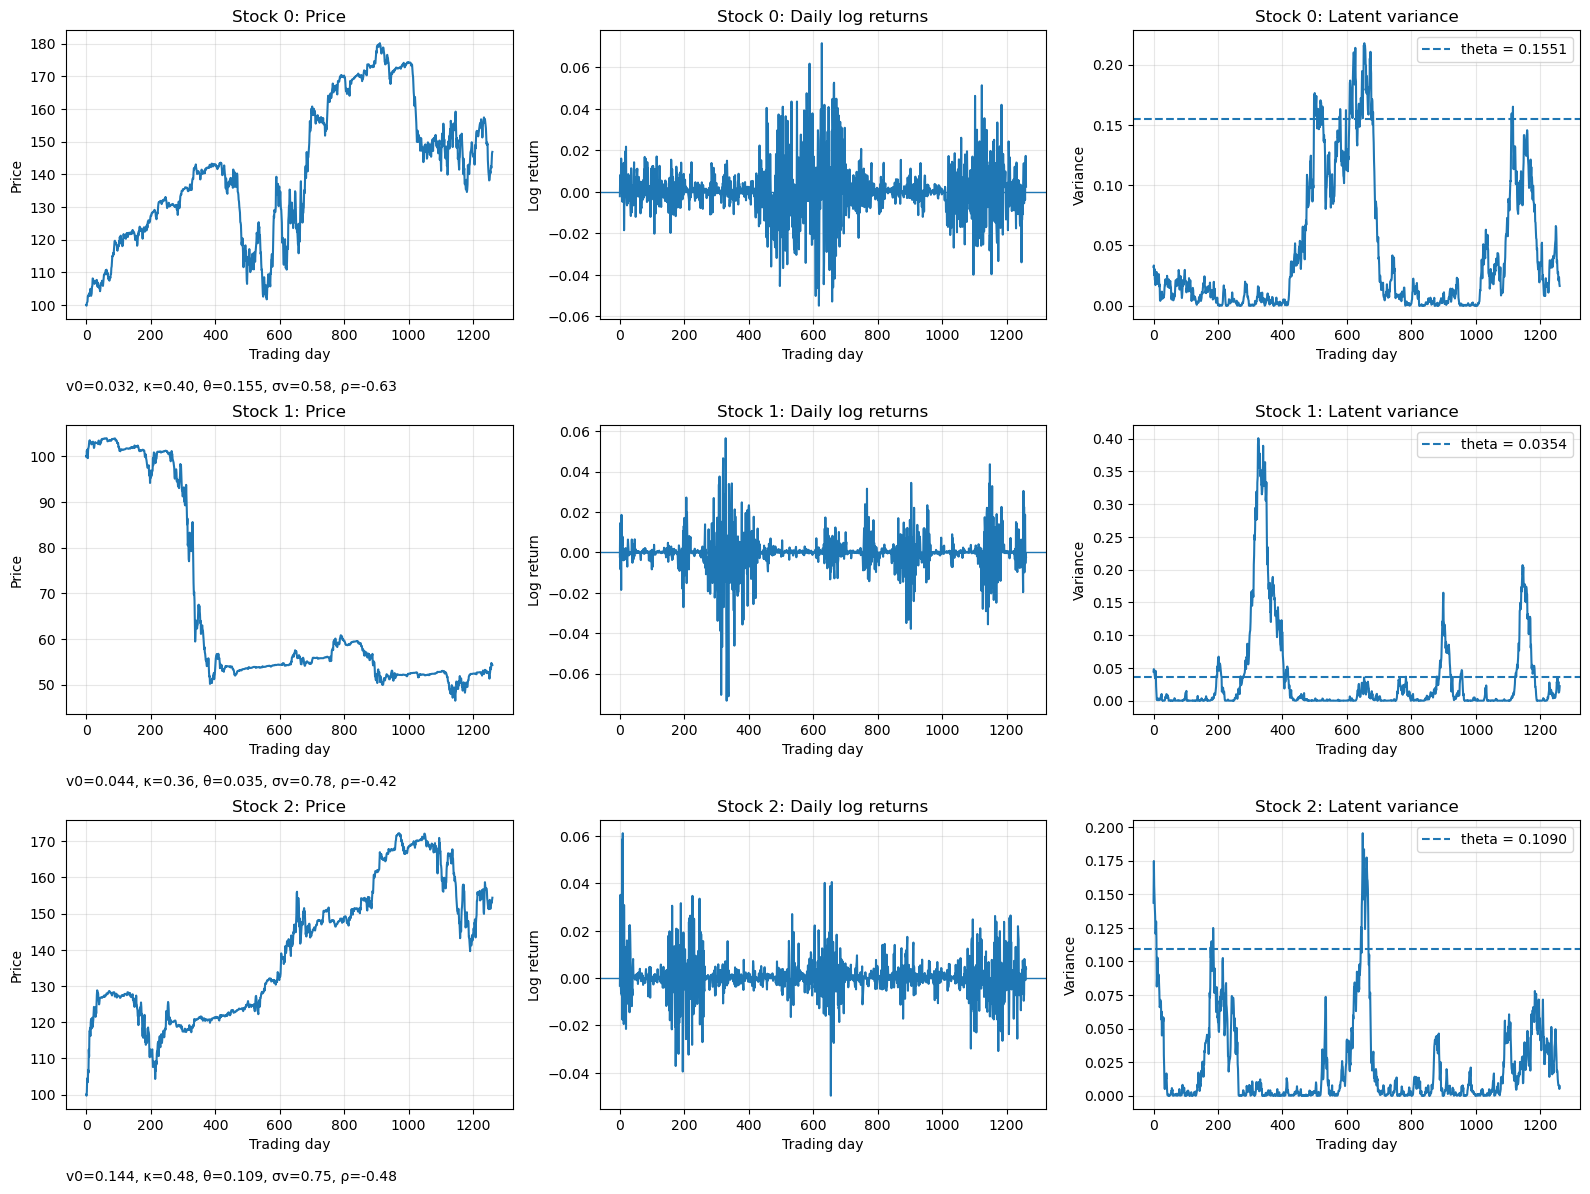

In [2]:
# ============================================================
# Inspect a few simulated stocks
# ============================================================

import matplotlib.pyplot as plt


# Pick a few paths to inspect.
path_indices = [0, 1, 2]

days = np.arange(prices.shape[1])
return_days = np.arange(1, log_returns.shape[1] + 1)

for path_index in path_indices:

    print("\n" + "=" * 60)
    print(f"Simulated stock {path_index}")
    print("=" * 60)

    for name, value in zip(parameter_names, labels[path_index]):
        print(f"{name:8s}: {value:.6f}")

    print(f"\nInitial annualized volatility: {np.sqrt(labels[path_index, 0]):.2%}")
    print(f"Long-run annualized volatility: {np.sqrt(labels[path_index, 2]):.2%}")

    print("\nFirst 10 daily log returns:")
    print(log_returns[path_index, :10])

    print("\nFirst 10 prices:")
    print(prices[path_index, :10])

    print("\nFirst 10 variance values:")
    print(variance_paths[path_index, :10])


# ============================================================
# Plot the selected paths
# ============================================================

fig, axes = plt.subplots(
    nrows=len(path_indices),
    ncols=3,
    figsize=(16, 4 * len(path_indices))
)

for row, path_index in enumerate(path_indices):

    v0, kappa, theta, sigma_v, rho = labels[path_index]

    title_parameters = (
        f"v0={v0:.3f}, κ={kappa:.2f}, θ={theta:.3f}, "
        f"σv={sigma_v:.2f}, ρ={rho:.2f}"
    )

    # --------------------------------------------------------
    # Price path
    # --------------------------------------------------------

    axes[row, 0].plot(days, prices[path_index])
    axes[row, 0].set_title(f"Stock {path_index}: Price")
    axes[row, 0].set_xlabel("Trading day")
    axes[row, 0].set_ylabel("Price")
    axes[row, 0].grid(alpha=0.3)

    # --------------------------------------------------------
    # Daily log returns
    # --------------------------------------------------------

    axes[row, 1].plot(return_days, log_returns[path_index])
    axes[row, 1].axhline(0, linewidth=1)
    axes[row, 1].set_title(f"Stock {path_index}: Daily log returns")
    axes[row, 1].set_xlabel("Trading day")
    axes[row, 1].set_ylabel("Log return")
    axes[row, 1].grid(alpha=0.3)

    # --------------------------------------------------------
    # Latent variance path
    # --------------------------------------------------------

    axes[row, 2].plot(days, variance_paths[path_index])
    axes[row, 2].axhline(
        theta,
        linestyle="--",
        linewidth=1.5,
        label=f"theta = {theta:.4f}"
    )
    axes[row, 2].set_title(f"Stock {path_index}: Latent variance")
    axes[row, 2].set_xlabel("Trading day")
    axes[row, 2].set_ylabel("Variance")
    axes[row, 2].grid(alpha=0.3)
    axes[row, 2].legend()

    # Put the parameter vector on the left side of each row.
    axes[row, 0].text(
        0.0,
        -0.25,
        title_parameters,
        transform=axes[row, 0].transAxes
    )

plt.tight_layout()
plt.show()